# Evolution of Heuristics for FEI Image Feature Extraction

This notebook adapts the **Evolution of Heuristics (EoH)** framework to discover interpretable feature-extraction programs for the FEI facial image dataset.

The experimental pipeline is:

> FEI image → EoH-generated feature function → feature vector → standardisation → Linear SVM → validation fitness

The notebook deliberately separates:

- **local development and validation**, which does not use API credits;
- **the paid EoH search**, which is disabled by default and must be enabled explicitly.

The final test set is held back throughout the search and should only be used once, after selecting the final evolved program.

## 1. Imports and project configuration

The notebook expects to be located inside the downloaded `EoH-main` folder. The FEI images are expected in `Downloads/originalimages_part1`.

No API request is made in this section.

## Corrected evaluation and smoke-test safeguards

This version addresses the failed initial EOH population by:

- increasing the local feature-evaluation limit;
- increasing the EOH worker evaluation timeout;
- validating each generated feature function on one image before full evaluation;
- printing detailed diagnostic information when a candidate fails;
- confirming that the fitness function returns a finite Python `float`;
- ensuring every paid EOH cell is genuinely controlled by a disabled safety flag.

All API-execution flags remain set to `False` by default.

In [2]:
from pathlib import Path
import ast
import inspect
import os
import sys
import time

import numpy as np
from skimage import color, io, transform
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

PROJECT_ROOT = Path.cwd()
FEI_DIR = Path.home() / "Downloads" / "originalimages_part1"

IMAGE_SIZE = (64, 64)
SELECTED_SUBJECTS = tuple(range(1, 11))
RANDOM_STATE = 42
TEST_SIZE = 0.30
VALIDATION_SIZE_WITHIN_DEVELOPMENT = 0.20

MAX_FEATURES = 5000
MAX_SECONDS_PER_EVALUATION = 150.0
INVALID_FITNESS = 0.0

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project folder:", PROJECT_ROOT)
print("FEI folder:", FEI_DIR)
print("Local EOH folder exists:", (PROJECT_ROOT / "eoh").exists())
print("FEI folder exists:", FEI_DIR.exists())

if not FEI_DIR.exists():
    raise FileNotFoundError(f"FEI dataset folder not found:\n{FEI_DIR}")

Project folder: c:\Users\james\Downloads
FEI folder: C:\Users\james\Downloads\originalimages_part1
Local EOH folder exists: False
FEI folder exists: True


## 2. Verify the EoH installation

This records the exact EoH package imported by Python. It is useful because a local repository and an installed `site-packages` copy can coexist.

In [3]:
import eoh
from eoh import BaseProblem, EoH, LLMConfig

EOH_LOCATION = Path(inspect.getfile(eoh)).resolve()

print("EOH imported successfully")
print("EOH location:", EOH_LOCATION)
print("Using local repository:", PROJECT_ROOT.resolve() in EOH_LOCATION.parents)
print("EoH signature:", inspect.signature(EoH))
print("LLMConfig signature:", inspect.signature(LLMConfig))

EOH imported successfully
EOH location: C:\Users\james\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\eoh\__init__.py
Using local repository: False
EoH signature: (llm: eoh.config.LLMConfig, problem, pop_size: int = 5, n_pop: int = 20, operators: list = None, operator_weights: list = None, n_parents: int = 2, num_samplers: int = 1, num_evaluators: int = 1, max_sample_nums: int = None, n_processes: int = None, output_dir: str = './', debug: bool = False, use_seed: bool = False, seed_path: str = './seeds/seeds.json', use_continue: bool = False, continue_path: str = './results/pops/population_generation_0.json', continue_id: int = 0)
LLMConfig signature: (api_endpoint: str = None, api_key: str = None, model: str = None, use_local: bool = False, local_url: str = None, timeout: int = 180) -> None


## 3. Load and preprocess the FEI dataset

The first ten identities are used, giving 140 images in total. Each image is converted to greyscale, resized to 64 × 64 pixels and stored as a `float32` NumPy array.

The subject number before the hyphen is used as the class label; for example, `10-06.jpg` belongs to subject 10.

In [4]:
def preprocess_image(image_path, image_size=IMAGE_SIZE):
    image = io.imread(image_path)

    if image.ndim == 3:
        image = color.rgb2gray(image)

    image = transform.resize(
        image,
        image_size,
        anti_aliasing=True,
        preserve_range=False,
    )

    return np.clip(
        np.asarray(image, dtype=np.float32),
        0.0,
        1.0,
    )


def infer_fei_subject_id(image_path):
    subject_text = image_path.stem.split("-")[0]

    try:
        return int(subject_text)
    except ValueError:
        return None


image_paths = sorted(
    list(FEI_DIR.glob("*.jpg"))
    + list(FEI_DIR.glob("*.jpeg"))
    + list(FEI_DIR.glob("*.png"))
)

if not image_paths:
    raise RuntimeError(f"No image files were found in:\n{FEI_DIR}")

print("Image files found:", len(image_paths))
print("Example filenames:", [path.name for path in image_paths[:5]])

Image files found: 700
Example filenames: ['1-01.jpg', '1-02.jpg', '1-03.jpg', '1-04.jpg', '1-05.jpg']


In [5]:
images = []
labels = []
used_paths = []

for image_path in image_paths:
    subject_id = infer_fei_subject_id(image_path)

    if subject_id not in SELECTED_SUBJECTS:
        continue

    images.append(preprocess_image(image_path))
    labels.append(subject_id - 1)
    used_paths.append(image_path)

if not images:
    raise RuntimeError("No selected FEI images were loaded.")

X_images = np.stack(images).astype(np.float32)
y = np.asarray(labels, dtype=np.int64)

print("Image array shape:", X_images.shape)
print("Label array shape:", y.shape)
print("Classes:", np.unique(y))
print("Pixel range:", float(X_images.min()), "to", float(X_images.max()))

for class_label in np.unique(y):
    print(f"Class {class_label}: {int(np.sum(y == class_label))} images")

Image array shape: (140, 64, 64)
Label array shape: (140,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel range: 0.0052183386869728565 to 0.824233889579773
Class 0: 14 images
Class 1: 14 images
Class 2: 14 images
Class 3: 14 images
Class 4: 14 images
Class 5: 14 images
Class 6: 14 images
Class 7: 14 images
Class 8: 14 images
Class 9: 14 images


## 4. Create fixed training, validation and test sets

The split is fixed for reproducibility:

- **training set:** fits the feature scaler and Linear SVM;
- **validation set:** supplies the EoH fitness score;
- **test set:** remains untouched until the final program has been selected.

The EoH search must never use `X_test` or `y_test`.

In [6]:
X_development, X_test, y_development, y_test = train_test_split(
    X_images,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=VALIDATION_SIZE_WITHIN_DEVELOPMENT,
    random_state=RANDOM_STATE,
    stratify=y_development,
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

for name, labels_subset in (
    ("Training", y_train),
    ("Validation", y_validation),
    ("Test", y_test),
):
    counts = {
        int(label): int(np.sum(labels_subset == label))
        for label in np.unique(labels_subset)
    }
    print(f"{name} class counts:", counts)

Training: (78, 64, 64) (78,)
Validation: (20, 64, 64) (20,)
Test: (42, 64, 64) (42,)
Training class counts: {0: 8, 1: 8, 2: 8, 3: 7, 4: 8, 5: 8, 6: 7, 7: 8, 8: 8, 9: 8}
Validation class counts: {0: 2, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 2, 9: 2}
Test class counts: {0: 4, 1: 4, 2: 4, 3: 5, 4: 4, 5: 4, 6: 5, 7: 4, 8: 4, 9: 4}


## 5. Candidate feature-function evaluator

Every candidate must return a finite, one-dimensional feature vector of constant length. The resulting feature matrices are standardised before fitting a Linear SVM.

The evaluator returns **validation accuracy**, where larger values are better. Invalid candidates return `0.0`.

In [7]:
def create_feature_matrix(images, feature_function):
    rows = []
    expected_length = None

    for image_number, image in enumerate(images):
        feature_vector = np.asarray(
            feature_function(image),
            dtype=np.float64,
        ).reshape(-1)

        if feature_vector.size == 0:
            raise ValueError(
                f"Image {image_number} produced an empty feature vector."
            )

        if feature_vector.size > MAX_FEATURES:
            raise ValueError(
                f"Candidate produced {feature_vector.size} features; "
                f"the limit is {MAX_FEATURES}."
            )

        if not np.all(np.isfinite(feature_vector)):
            raise ValueError(
                f"Image {image_number} produced non-finite values."
            )

        if expected_length is None:
            expected_length = feature_vector.size
        elif feature_vector.size != expected_length:
            raise ValueError(
                "Candidate returned inconsistent feature lengths: "
                f"expected {expected_length}, received {feature_vector.size}."
            )

        rows.append(feature_vector)

    return np.vstack(rows)


def evaluate_feature_function(feature_function, verbose=True):
    start_time = time.perf_counter()

    try:
        train_features = create_feature_matrix(
            X_train,
            feature_function,
        )
        validation_features = create_feature_matrix(
            X_validation,
            feature_function,
        )

        extraction_runtime = time.perf_counter() - start_time
        if extraction_runtime > MAX_SECONDS_PER_EVALUATION:
            raise TimeoutError(
                "Feature extraction exceeded the evaluation time limit."
            )

        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_features)
        validation_scaled = scaler.transform(validation_features)

        classifier = LinearSVC(
            C=1.0,
            random_state=RANDOM_STATE,
            max_iter=10000,
        )
        classifier.fit(train_scaled, y_train)

        predictions = classifier.predict(validation_scaled)
        accuracy = accuracy_score(y_validation, predictions)
        total_runtime = time.perf_counter() - start_time

        if verbose:
            print("Candidate evaluated successfully")
            print("Training feature matrix:", train_features.shape)
            print("Validation accuracy:", f"{accuracy * 100:.2f}%")
            print("Runtime:", f"{total_runtime:.3f} seconds")

        return float(accuracy)

    except Exception as error:
        if verbose:
            print("Candidate evaluation failed")
            print(f"{type(error).__name__}: {error}")

        return INVALID_FITNESS

## 6. Local evaluator tests

These handcrafted candidates test the full local path from feature extraction to SVM validation accuracy. They do not contact an external API.

In [8]:
def basic_statistical_features(image):
    return np.array(
        [
            np.mean(image),
            np.std(image),
            np.min(image),
            np.max(image),
            np.median(image),
            np.percentile(image, 25),
            np.percentile(image, 75),
        ],
        dtype=np.float64,
    )


def histogram_statistical_features(image):
    histogram, _ = np.histogram(
        image,
        bins=16,
        range=(0.0, 1.0),
    )

    statistics = np.array(
        [
            np.mean(image),
            np.std(image),
            np.median(image),
            np.percentile(image, 25),
            np.percentile(image, 75),
        ],
        dtype=np.float64,
    )

    return np.concatenate([statistics, histogram.astype(float)])


basic_accuracy = evaluate_feature_function(
    basic_statistical_features,
    verbose=True,
)

histogram_accuracy = evaluate_feature_function(
    histogram_statistical_features,
    verbose=True,
)

print("Basic statistical accuracy:", f"{basic_accuracy * 100:.2f}%")
print("Histogram/statistical accuracy:", f"{histogram_accuracy * 100:.2f}%")

Candidate evaluated successfully
Training feature matrix: (78, 7)
Validation accuracy: 75.00%
Runtime: 0.028 seconds
Candidate evaluated successfully
Training feature matrix: (78, 21)
Validation accuracy: 80.00%
Runtime: 0.034 seconds
Basic statistical accuracy: 75.00%
Histogram/statistical accuracy: 80.00%


## 7. Define the FEI problem for EoH

EoH minimises fitness, so this wrapper returns:

\[
	ext{fitness} = 1 - 	ext{validation accuracy}.
\]

A perfect validation accuracy therefore has fitness `0.0`.

The prompt restricts generated functions to deterministic, NumPy-only feature extraction. This reduces invalid programs and keeps the search focused on interpretable image measurements.

In [9]:
# Write the EOH problem to an importable Python module.
#
# This fixes Windows multiprocessing issues: EOH evaluates candidates in
# spawned worker processes, which cannot reliably access notebook-local
# classes, functions or global arrays.

PROBLEM_MODULE_PATH = PROJECT_ROOT / "fei_eoh_problem.py"

PROBLEM_MODULE_SOURCE = 'from __future__ import annotations\n\nimport time\nimport traceback\n\nimport numpy as np\nfrom sklearn.metrics import accuracy_score\nfrom sklearn.pipeline import make_pipeline\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.svm import LinearSVC\n\nfrom eoh import BaseProblem\n\n\nclass FEIFeatureExtractionProblem(BaseProblem):\n    """\n    Importable EOH problem for FEI feature extraction.\n\n    Keeping this class in a real Python module is important on Windows because\n    EOH evaluates candidates in worker processes. Notebook-local classes and\n    notebook globals are not reliably available in spawned child processes.\n    """\n\n    template_program = """\nimport numpy as np\n\ndef extract_features(image: np.ndarray) -> np.ndarray:\n    \\"""Return a finite, fixed-length, one-dimensional feature vector.\\"""\n    image = np.asarray(image, dtype=float)\n\n    features = np.array(\n        [\n            np.mean(image),\n            np.std(image),\n            np.median(image),\n        ],\n        dtype=float,\n    )\n\n    return features\n"""\n\n    task_description = (\n        "Improve the NumPy-only extract_features function for ten-class "\n        "facial identity classification. The input is one 64 by 64 "\n        "grayscale NumPy array. The function must be named extract_features "\n        "and accept exactly one image argument. Return a finite, fixed-length, "\n        "one-dimensional NumPy array containing between 1 and 5000 values. "\n        "Use only NumPy and deterministic local computation. Do not access "\n        "files, networks, random number generators, classifiers, labels, "\n        "global datasets or external libraries. Prefer interpretable "\n        "statistics, regional summaries, gradients, histograms and "\n        "texture-like measurements. Fitness is 1 minus validation accuracy "\n        "from a fixed Linear SVM, so lower fitness is better."\n    )\n\n    def __init__(\n        self,\n        X_train: np.ndarray,\n        y_train: np.ndarray,\n        X_validation: np.ndarray,\n        y_validation: np.ndarray,\n        *,\n        timeout: int = 180,\n        n_processes: int = 1,\n        max_features: int = 5000,\n        max_seconds_per_evaluation: float = 150.0,\n    ) -> None:\n        super().__init__(timeout=timeout, n_processes=n_processes)\n\n        self.X_train = np.asarray(X_train)\n        self.y_train = np.asarray(y_train)\n        self.X_validation = np.asarray(X_validation)\n        self.y_validation = np.asarray(y_validation)\n\n        self.max_features = int(max_features)\n        self.max_seconds_per_evaluation = float(\n            max_seconds_per_evaluation\n        )\n\n    def _build_feature_matrix(\n        self,\n        images: np.ndarray,\n        feature_function,\n    ) -> np.ndarray:\n        rows = []\n        expected_size = None\n        started = time.perf_counter()\n\n        for image_index, image in enumerate(images):\n            if (\n                time.perf_counter() - started\n                > self.max_seconds_per_evaluation\n            ):\n                raise TimeoutError(\n                    "Feature extraction exceeded the local evaluation "\n                    f"limit of {self.max_seconds_per_evaluation:.1f} seconds."\n                )\n\n            features = np.asarray(\n                feature_function(image),\n                dtype=np.float64,\n            ).reshape(-1)\n\n            if features.size == 0:\n                raise ValueError(\n                    f"Image {image_index} produced an empty feature vector."\n                )\n\n            if features.size > self.max_features:\n                raise ValueError(\n                    f"Image {image_index} produced {features.size} "\n                    f"features; the limit is {self.max_features}."\n                )\n\n            if not np.all(np.isfinite(features)):\n                raise ValueError(\n                    f"Image {image_index} produced NaN or infinite values."\n                )\n\n            if expected_size is None:\n                expected_size = features.size\n            elif features.size != expected_size:\n                raise ValueError(\n                    "The generated feature extractor returned vectors of "\n                    f"different lengths: expected {expected_size}, got "\n                    f"{features.size} for image {image_index}."\n                )\n\n            rows.append(features)\n\n        return np.vstack(rows)\n\n    def _validation_accuracy(self, feature_function) -> float:\n        train_features = self._build_feature_matrix(\n            self.X_train,\n            feature_function,\n        )\n        validation_features = self._build_feature_matrix(\n            self.X_validation,\n            feature_function,\n        )\n\n        classifier = make_pipeline(\n            StandardScaler(),\n            LinearSVC(\n                random_state=42,\n                dual="auto",\n                max_iter=10000,\n            ),\n        )\n\n        classifier.fit(train_features, self.y_train)\n        predictions = classifier.predict(validation_features)\n\n        return float(\n            accuracy_score(self.y_validation, predictions)\n        )\n\n    def evaluate_program(\n        self,\n        program_str: str,\n        callable_func,\n    ) -> float | None:\n        """\n        Return finite float fitness, or None when a candidate is invalid.\n        """\n        started = time.perf_counter()\n\n        try:\n            if callable_func is None:\n                raise TypeError(\n                    "EOH did not provide a callable generated function."\n                )\n\n            sample_features = np.asarray(\n                callable_func(self.X_train[0]),\n                dtype=np.float64,\n            ).reshape(-1)\n\n            if sample_features.size == 0:\n                raise ValueError(\n                    "The generated feature vector is empty."\n                )\n\n            if sample_features.size > self.max_features:\n                raise ValueError(\n                    f"The generated feature vector contains "\n                    f"{sample_features.size} values; the limit is "\n                    f"{self.max_features}."\n                )\n\n            if not np.all(np.isfinite(sample_features)):\n                raise ValueError(\n                    "The generated feature vector contains NaN or "\n                    "infinite values."\n                )\n\n            validation_accuracy = self._validation_accuracy(\n                callable_func\n            )\n\n            if not np.isfinite(validation_accuracy):\n                raise ValueError(\n                    "The evaluator returned non-finite validation accuracy."\n                )\n\n            if not 0.0 <= validation_accuracy <= 1.0:\n                raise ValueError(\n                    "Validation accuracy lies outside [0, 1]."\n                )\n\n            fitness = float(1.0 - validation_accuracy)\n\n            # Worker-process diagnostics are also persisted to a file because\n            # subprocess stdout may not appear in a Jupyter notebook.\n            self._write_diagnostic(\n                status="success",\n                program_str=program_str,\n                message=(\n                    f"accuracy={validation_accuracy:.6f}, "\n                    f"fitness={fitness:.6f}, "\n                    f"runtime={time.perf_counter() - started:.3f}s"\n                ),\n            )\n\n            return fitness\n\n        except Exception as error:\n            self._write_diagnostic(\n                status="failure",\n                program_str=program_str,\n                message=(\n                    f"{type(error).__name__}: {error}\\n"\n                    f"{traceback.format_exc()}"\n                ),\n            )\n            return None\n\n    def _write_diagnostic(\n        self,\n        *,\n        status: str,\n        program_str: str,\n        message: str,\n    ) -> None:\n        """\n        Persist diagnostics from worker processes.\n\n        Failures in diagnostic writing are deliberately ignored so logging\n        cannot itself invalidate a candidate.\n        """\n        try:\n            from datetime import datetime\n            from pathlib import Path\n            import os\n\n            diagnostics_dir = (\n                Path.cwd()\n                / "results"\n                / "fei_eoh"\n                / "candidate_diagnostics"\n            )\n            diagnostics_dir.mkdir(parents=True, exist_ok=True)\n\n            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")\n            process_id = os.getpid()\n            path = diagnostics_dir / (\n                f"{timestamp}_{process_id}_{status}.txt"\n            )\n\n            path.write_text(\n                f"STATUS: {status}\\n\\n"\n                f"MESSAGE:\\n{message}\\n\\n"\n                f"PROGRAM:\\n{program_str}\\n",\n                encoding="utf-8",\n            )\n        except Exception:\n            pass\n'

PROBLEM_MODULE_PATH.write_text(
    PROBLEM_MODULE_SOURCE,
    encoding="utf-8",
)

# Reload the module so notebook edits are picked up without restarting Python.
import importlib
import fei_eoh_problem

importlib.reload(fei_eoh_problem)

FEIFeatureExtractionProblem = (
    fei_eoh_problem.FEIFeatureExtractionProblem
)

fei_problem = FEIFeatureExtractionProblem(
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
    timeout=180,
    n_processes=1,
    max_features=MAX_FEATURES,
    max_seconds_per_evaluation=150.0,
)

print("Problem module:", PROBLEM_MODULE_PATH.resolve())
print("Problem class module:", FEIFeatureExtractionProblem.__module__)
print("Problem created:", type(fei_problem).__name__)
print("EOH evaluation timeout: 180 seconds")
print("Local feature-evaluation limit: 150 seconds")


Problem module: C:\Users\james\Downloads\fei_eoh_problem.py
Problem class module: fei_eoh_problem
Problem created: FEIFeatureExtractionProblem
EOH evaluation timeout: 180 seconds
Local feature-evaluation limit: 150 seconds


## Diagnostic test of the corrected EOH fitness function

This local test sends an existing handcrafted feature extractor through the same
`evaluate_program` method used for EOH-generated candidates.

It confirms that:

- a feature function can be executed;
- a fixed-length feature matrix is produced;
- validation accuracy is calculated;
- fitness is returned as a finite Python `float`;
- no DeepSeek API request is made.

In [10]:
diagnostic_fitness = fei_problem.evaluate_program(
    program_str="""
import numpy as np

def extract_features(image):
    image = np.asarray(image, dtype=float)
    histogram, _ = np.histogram(
        image,
        bins=16,
        range=(0.0, 1.0),
        density=True,
    )
    return np.concatenate(
        [
            histogram,
            np.array(
                [
                    np.mean(image),
                    np.std(image),
                    np.median(image),
                    np.min(image),
                    np.max(image),
                ]
            ),
        ]
    )
""",
    callable_func=histogram_statistical_features,
)

print()
print("=" * 70)
print("IMPORTABLE-MODULE FITNESS DIAGNOSTIC")
print("=" * 70)
print("Fitness:", diagnostic_fitness)

if diagnostic_fitness is None:
    raise RuntimeError(
        "The importable-module fitness diagnostic returned None."
    )

if not isinstance(diagnostic_fitness, float):
    raise TypeError(
        "The fitness diagnostic did not return a Python float."
    )

if not np.isfinite(diagnostic_fitness):
    raise ValueError(
        "The fitness diagnostic returned a non-finite value."
    )

print(
    "Recovered validation accuracy:",
    f"{(1.0 - diagnostic_fitness) * 100:.2f}%",
)
print("PASS: Importable problem module works locally.")
print("No API request was made.")



IMPORTABLE-MODULE FITNESS DIAGNOSTIC
Fitness: 0.19999999999999996
Recovered validation accuracy: 80.00%
PASS: Importable problem module works locally.
No API request was made.


## Importable problem-module compatibility check

The EOH problem class is stored in the standalone `fei_eoh_problem.py` module
so that it can be imported outside the notebook.

This check verifies that:

- the class comes from the correct Python module;
- the problem object can be serialised with `pickle`;
- the problem object can be restored successfully;
- the restored object can evaluate a feature extractor.

This check does not launch a multiprocessing pool, contact DeepSeek or consume
API credits.

In [11]:
import pickle

print("=" * 70)
print("IMPORTABLE PROBLEM-MODULE CHECK")
print("=" * 70)

print(
    "Problem class module:",
    FEIFeatureExtractionProblem.__module__,
)

if FEIFeatureExtractionProblem.__module__ != "fei_eoh_problem":
    raise RuntimeError(
        "The problem class is not being imported from fei_eoh_problem."
    )

serialised_problem = pickle.dumps(fei_problem)
restored_problem = pickle.loads(serialised_problem)

print("Serialisation: PASS")
print("Restored type:", type(restored_problem).__name__)

def restored_test_features(image):
    image = np.asarray(image, dtype=float)

    return np.array(
        [
            np.mean(image),
            np.std(image),
            np.median(image),
        ],
        dtype=float,
    )

restored_fitness = restored_problem.evaluate_program(
    program_str="""
import numpy as np

def extract_features(image):
    image = np.asarray(image, dtype=float)

    return np.array(
        [
            np.mean(image),
            np.std(image),
            np.median(image),
        ],
        dtype=float,
    )
""",
    callable_func=restored_test_features,
)

print("Restored problem fitness:", restored_fitness)

if restored_fitness is None:
    raise RuntimeError(
        "The restored problem object failed its local evaluation."
    )

if not isinstance(restored_fitness, float):
    raise TypeError(
        "The restored problem did not return a Python float."
    )

print("PASS: The problem module is importable and serialisable.")
print("No API request was made.")

IMPORTABLE PROBLEM-MODULE CHECK
Problem class module: fei_eoh_problem
Serialisation: PASS
Restored type: FEIFeatureExtractionProblem
Restored problem fitness: 0.6
PASS: The problem module is importable and serialisable.
No API request was made.


## Enable detailed EOH evaluation logging

The installed EOH package catches candidate compilation and evaluation errors
inside `BaseProblem.evaluate()` and records them only at the `DEBUG` logging
level.

This cell enables detailed EOH logging so that syntax errors, missing function
names and runtime exceptions are displayed instead of being reduced to the
message `evaluation failed`.

Running this cell does not make an API request.

In [12]:
import logging
import sys

# Enable debugging for the main EOH logger and all child loggers.
eoh_logger = logging.getLogger("eoh")
eoh_logger.setLevel(logging.DEBUG)

if not any(
    getattr(handler, "_eoh_debug_handler", False)
    for handler in eoh_logger.handlers
):
    debug_handler = logging.StreamHandler(sys.stdout)
    debug_handler.setLevel(logging.DEBUG)
    debug_handler.setFormatter(
        logging.Formatter(
            "[%(asctime)s] %(name)s %(levelname)s: %(message)s",
            datefmt="%H:%M:%S",
        )
    )
    debug_handler._eoh_debug_handler = True
    eoh_logger.addHandler(debug_handler)

eoh_logger.propagate = False

print("EOH debug logging enabled.")
print("Logger level:", logging.getLevelName(eoh_logger.level))
print("No API request was made.")

EOH debug logging enabled.
Logger level: DEBUG
No API request was made.


## Test the EOH compilation wrapper locally

These tests call `fei_problem.evaluate()` directly.

The first program is valid and must produce a finite fitness value. The second
program is deliberately invalid and must return `None` while printing the real
exception through the EOH debug logger.

These tests verify the same compilation wrapper used during an EOH search.
Neither test contacts DeepSeek.

In [13]:
valid_program = """
import numpy as np

def extract_features(image):
    image = np.asarray(image, dtype=float)

    return np.array(
        [
            np.mean(image),
            np.std(image),
            np.median(image),
        ],
        dtype=float,
    )
"""

valid_wrapper_fitness = fei_problem.evaluate(valid_program)

print("=" * 70)
print("VALID EOH WRAPPER TEST")
print("=" * 70)
print("Fitness:", valid_wrapper_fitness)

if valid_wrapper_fitness is None:
    raise RuntimeError(
        "The EOH compilation wrapper rejected a known valid program."
    )

if not isinstance(valid_wrapper_fitness, float):
    raise TypeError(
        "The EOH compilation wrapper did not return a Python float."
    )

if not np.isfinite(valid_wrapper_fitness):
    raise ValueError(
        "The EOH compilation wrapper returned non-finite fitness."
    )

print("PASS: Known valid program was compiled and evaluated.")
print("No API request was made.")

VALID EOH WRAPPER TEST
Fitness: 0.6
PASS: Known valid program was compiled and evaluated.
No API request was made.


In [14]:
invalid_program = """
import numpy as np

def extract_features(image):
    return np.this_function_does_not_exist(image)
"""

invalid_wrapper_fitness = fei_problem.evaluate(invalid_program)

print()
print("=" * 70)
print("INVALID EOH WRAPPER TEST")
print("=" * 70)
print("Fitness:", invalid_wrapper_fitness)

if invalid_wrapper_fitness is not None:
    raise RuntimeError(
        "The deliberately invalid program unexpectedly received fitness."
    )

print("PASS: Invalid program was rejected as expected.")
print(
    "The EOH DEBUG output above should show the underlying "
    "AttributeError."
)
print("No API request was made.")


INVALID EOH WRAPPER TEST
Fitness: None
PASS: Invalid program was rejected as expected.
The EOH DEBUG output above should show the underlying AttributeError.
No API request was made.


## Inspect the installed EOH evaluation wrapper

The installed package compiles generated code in `BaseProblem.evaluate()` and
silently converts exceptions to `None`.

This read-only inspection records the exact package location and relevant source
lines for reproducibility. It does not alter the installed package and makes no
API request.

In [15]:
from pathlib import Path
import inspect
import eoh

EOH_PACKAGE_DIRECTORY = Path(inspect.getfile(eoh)).resolve().parent
EOH_PROBLEM_FILE = EOH_PACKAGE_DIRECTORY / "problem.py"

print("EOH package directory:")
print(EOH_PACKAGE_DIRECTORY)
print()
print("Problem source file:")
print(EOH_PROBLEM_FILE)
print()
print("Directory exists:", EOH_PACKAGE_DIRECTORY.exists())
print("Problem file exists:", EOH_PROBLEM_FILE.exists())
print("No API request was made.")

EOH package directory:
C:\Users\james\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\eoh

Problem source file:
C:\Users\james\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\eoh\problem.py

Directory exists: True
Problem file exists: True
No API request was made.


In [16]:
problem_source_lines = EOH_PROBLEM_FILE.read_text(
    encoding="utf-8",
    errors="replace",
).splitlines()

print("EOH BaseProblem.evaluate() source context")
print("=" * 80)

for line_number in range(92, 114):
    print(
        f"{line_number:4d}: "
        f"{problem_source_lines[line_number - 1]}"
    )

print()
print(
    "The wrapper logs exceptions at DEBUG level and then returns None."
)
print("No API request was made.")

EOH BaseProblem.evaluate() source context
  92:     def evaluate(self, code_string: str) -> float | None:
  93:         """Called by the framework. Compiles code_string then delegates to evaluate_program."""
  94:         try:
  95:             with warnings.catch_warnings():
  96:                 warnings.simplefilter("ignore")
  97:                 import numpy as np
  98:                 module = types.ModuleType(f"heuristic_module_{next(_module_counter)}")
  99:                 import_prefix = _extract_import_lines(self.template_program)
 100:                 if import_prefix:
 101:                     exec(import_prefix, module.__dict__)
 102:                 module.__dict__.setdefault('np', np)
 103:                 exec(code_string, module.__dict__)
 104:                 sys.modules[module.__name__] = module
 105:                 entry_name = _get_entry_name(self.template_program)
 106:                 callable_obj = getattr(module, entry_name, None)
 107:                 if cal

## 8. Configure DeepSeek securely

The API key is read from the `DEEPSEEK_API_KEY` environment variable. The notebook never contains or prints the key itself.

Before continuing:

1. ensure the key has been stored locally;
2. restart VS Code after setting the environment variable;
3. revoke and replace any key that has previously appeared in screenshots or notebook output.

Creating the configuration object does **not** make an API request.

In [17]:
deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

if not deepseek_api_key:
    raise EnvironmentError(
        "DEEPSEEK_API_KEY was not found. Set it locally, restart VS Code "
        "and run the notebook again."
    )

llm_config = LLMConfig(
    api_endpoint="api.deepseek.com",
    api_key=deepseek_api_key,
    model="deepseek-v4-flash",
    timeout=180,
)

print("LLM configuration created")
print("Endpoint:", llm_config.api_endpoint)
print("Model:", llm_config.model)
print("Timeout:", llm_config.timeout)
print("API key loaded:", bool(llm_config.api_key))

LLM configuration created
Endpoint: api.deepseek.com
Model: deepseek-v4-flash
Timeout: 180
API key loaded: True


## 9. Configure a minimal EoH smoke test

This configuration is intentionally small:

- population size: 2;
- one population;
- one E1 operator;
- one sampler and one evaluator.

Constructing the runner is local. The API is contacted only when `eoh_runner.run()` is called.

In [18]:
# Recreate the runner after constructing the corrected problem object.
eoh_runner = EoH(
    llm=llm_config,
    problem=fei_problem,
    pop_size=2,
    n_pop=1,
    operators=["e1"],
    num_samplers=1,
    num_evaluators=1,
)

print("Minimal corrected EOH runner configured")
print("Population size:", eoh_runner._config.pop_size)
print("Populations:", eoh_runner._config.n_pop)
print("Operators:", eoh_runner._config.operators)
print(
    "Runner uses corrected FEI problem:",
    eoh_runner._problem is fei_problem,
)
print("Configured evaluation timeout: 180 seconds")
print("No API request has been made.")

Minimal corrected EOH runner configured
Population size: 2
Populations: 1
Operators: ['e1']
Runner uses corrected FEI problem: True
Configured evaluation timeout: 180 seconds
No API request has been made.


## 10. Final local preflight

Every check below must pass before enabling the paid search. This cell does not contact DeepSeek.

In [19]:
checks = {
    "API key loaded": bool(os.getenv("DEEPSEEK_API_KEY")),
    "Endpoint correct":
        eoh_runner._config.llm.api_endpoint == "api.deepseek.com",
    "Model configured":
        bool(eoh_runner._config.llm.model),
    "Population size is 2":
        eoh_runner._config.pop_size == 2,
    "One population":
        eoh_runner._config.n_pop == 1,
    "Only E1 enabled":
        eoh_runner._config.operators == ["e1"],
    "Correct problem attached":
        eoh_runner._problem is fei_problem,
    "Template parses":
        bool(ast.parse(fei_problem.template_program)),
    "Corrected local time limit":
        MAX_SECONDS_PER_EVALUATION == 150.0,
    "Run method exists":
        callable(getattr(eoh_runner, "run", None)),
}

print("FINAL LOCAL PREFLIGHT")
print("-" * 55)

for name, passed in checks.items():
    print(f"{name:<32} {'PASS' if passed else 'FAIL'}")

if not all(checks.values()):
    failed = [name for name, passed in checks.items() if not passed]
    raise RuntimeError(
        "Do not start the API run. Failed checks: "
        + ", ".join(failed)
    )

manual_accuracy = evaluate_feature_function(
    histogram_statistical_features,
    verbose=False,
)

print("-" * 55)
print(f"Manual evaluator accuracy: {manual_accuracy * 100:.2f}%")
print("All local checks passed.")
print("The next enabled run command will use API credits.")

FINAL LOCAL PREFLIGHT
-------------------------------------------------------
API key loaded                   PASS
Endpoint correct                 PASS
Model configured                 PASS
Population size is 2             PASS
One population                   PASS
Only E1 enabled                  PASS
Correct problem attached         PASS
Template parses                  PASS
Corrected local time limit       PASS
Run method exists                PASS


-------------------------------------------------------
Manual evaluator accuracy: 80.00%
All local checks passed.
The next enabled run command will use API credits.


## 11. Paid EoH smoke test — disabled by default

The following cell is the **first part of the notebook that can consume API credits**.

It remains disabled unless `RUN_PAID_EOH` is deliberately changed to `True`. Keep it as `False` while reviewing or rerunning the notebook.

In [20]:
RUN_PAID_EOH = False

if RUN_PAID_EOH:
    print("Starting the paid EOH smoke test...")
    eoh_runner.run()
else:
    print("Paid EOH search not started.")
    print("Set RUN_PAID_EOH = True only when authorised to use API credits.")

Paid EOH search not started.
Set RUN_PAID_EOH = True only when authorised to use API credits.


## 12. Final test evaluation

Do not evaluate the test set during EoH evolution. After the search has finished and one final program has been selected using validation performance, pass its callable feature function to `evaluate_final_candidate`.

This provides a single unbiased estimate of final classification performance.

In [21]:
def evaluate_final_candidate(feature_function, verbose=True):
    development_features = create_feature_matrix(
        X_development,
        feature_function,
    )
    test_features = create_feature_matrix(
        X_test,
        feature_function,
    )

    scaler = StandardScaler()
    development_scaled = scaler.fit_transform(development_features)
    test_scaled = scaler.transform(test_features)

    classifier = LinearSVC(
        C=1.0,
        random_state=RANDOM_STATE,
        max_iter=10000,
    )
    classifier.fit(development_scaled, y_development)

    test_predictions = classifier.predict(test_scaled)
    test_accuracy = accuracy_score(y_test, test_predictions)

    if verbose:
        print("Final development feature matrix:", development_features.shape)
        print("Final test accuracy:", f"{test_accuracy * 100:.2f}%")

    return float(test_accuracy)


# Example, only after selecting the final evolved callable:
# final_test_accuracy = evaluate_final_candidate(best_evolved_function)

## 13. Experiment logging and result storage

The following utilities create a reproducible record of each EoH run.

They save:

- experiment metadata;
- timestamps;
- model and search settings;
- validation results;
- generated program text when available;
- the selected best program;
- final test accuracy after explicit evaluation.

All files are written beneath `results/fei_eoh/`.

In [22]:
from datetime import datetime, timezone
import csv
import json

RESULTS_ROOT = PROJECT_ROOT / "results" / "fei_eoh"
PROGRAMS_DIRECTORY = RESULTS_ROOT / "generated_programs"
LOG_CSV_PATH = RESULTS_ROOT / "experiment_log.csv"
METADATA_JSON_PATH = RESULTS_ROOT / "latest_run_metadata.json"

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
PROGRAMS_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Results folder:", RESULTS_ROOT.resolve())
print("Program folder:", PROGRAMS_DIRECTORY.resolve())

Results folder: C:\Users\james\Downloads\results\fei_eoh
Program folder: C:\Users\james\Downloads\results\fei_eoh\generated_programs


In [23]:
def utc_timestamp():
    return datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")


def save_program_text(program_text, label):
    safe_label = "".join(
        character if character.isalnum() or character in {"_", "-"}
        else "_"
        for character in label
    )

    path = PROGRAMS_DIRECTORY / f"{safe_label}.py"
    path.write_text(program_text, encoding="utf-8")
    return path


def append_experiment_log(record):
    fieldnames = [
        "timestamp_utc",
        "model",
        "endpoint",
        "population_size",
        "n_pop",
        "operators",
        "validation_accuracy",
        "fitness",
        "runtime_seconds",
        "program_path",
        "test_accuracy",
        "status",
        "notes",
    ]

    file_exists = LOG_CSV_PATH.exists()

    with LOG_CSV_PATH.open("a", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)

        if not file_exists:
            writer.writeheader()

        writer.writerow({
            field: record.get(field)
            for field in fieldnames
        })


def save_run_metadata(extra=None):
    metadata = {
        "timestamp_utc": utc_timestamp(),
        "eoh_location": str(EOH_LOCATION),
        "dataset_directory": str(FEI_DIR),
        "image_shape": list(IMAGE_SIZE),
        "selected_subjects": list(SELECTED_SUBJECTS),
        "random_state": RANDOM_STATE,
        "training_size": int(len(X_train)),
        "validation_size": int(len(X_validation)),
        "test_size": int(len(X_test)),
        "model": eoh_runner._config.llm.model,
        "endpoint": eoh_runner._config.llm.api_endpoint,
        "population_size": int(eoh_runner._config.pop_size),
        "n_pop": int(eoh_runner._config.n_pop),
        "operators": list(eoh_runner._config.operators),
    }

    if extra:
        metadata.update(extra)

    METADATA_JSON_PATH.write_text(
        json.dumps(metadata, indent=2),
        encoding="utf-8",
    )

    return metadata


metadata = save_run_metadata({
    "status": "configured_not_run",
})

print("Metadata saved:", METADATA_JSON_PATH.resolve())

Metadata saved: C:\Users\james\Downloads\results\fei_eoh\latest_run_metadata.json


## 14. Run EoH with timing and metadata capture

This cell remains disabled by default. It wraps the paid EoH call with timing and metadata logging.

The exact return object depends on the installed EoH version, so the raw result is preserved in `eoh_run_result` for inspection.

In [24]:
RUN_PAID_EOH_WITH_LOGGING = False

eoh_run_result = None
eoh_run_runtime = None

if RUN_PAID_EOH_WITH_LOGGING:
    run_started = time.perf_counter()
    run_timestamp = utc_timestamp()

    try:
        eoh_run_result = eoh_runner.run()
        eoh_run_runtime = time.perf_counter() - run_started

        save_run_metadata({
            "status": "completed",
            "run_timestamp_utc": run_timestamp,
            "runtime_seconds": eoh_run_runtime,
            "result_type": type(eoh_run_result).__name__,
            "result_repr": repr(eoh_run_result)[:5000],
        })

        append_experiment_log({
            "timestamp_utc": run_timestamp,
            "model": eoh_runner._config.llm.model,
            "endpoint": eoh_runner._config.llm.api_endpoint,
            "population_size": eoh_runner._config.pop_size,
            "n_pop": eoh_runner._config.n_pop,
            "operators": ",".join(eoh_runner._config.operators),
            "runtime_seconds": eoh_run_runtime,
            "status": "completed",
            "notes": "Raw EoH run completed; inspect result object and output files.",
        })

        print("EOH run completed")
        print("Runtime:", f"{eoh_run_runtime:.2f} seconds")
        print("Result type:", type(eoh_run_result).__name__)

    except Exception as error:
        eoh_run_runtime = time.perf_counter() - run_started

        save_run_metadata({
            "status": "failed",
            "run_timestamp_utc": run_timestamp,
            "runtime_seconds": eoh_run_runtime,
            "error_type": type(error).__name__,
            "error_message": str(error),
        })

        append_experiment_log({
            "timestamp_utc": run_timestamp,
            "model": eoh_runner._config.llm.model,
            "endpoint": eoh_runner._config.llm.api_endpoint,
            "population_size": eoh_runner._config.pop_size,
            "n_pop": eoh_runner._config.n_pop,
            "operators": ",".join(eoh_runner._config.operators),
            "runtime_seconds": eoh_run_runtime,
            "status": "failed",
            "notes": f"{type(error).__name__}: {error}",
        })

        raise

else:
    print("Paid EOH run not started.")
    print("Set RUN_PAID_EOH_WITH_LOGGING = True only when authorised.")

Paid EOH run not started.
Set RUN_PAID_EOH_WITH_LOGGING = True only when authorised.


## 15. Save and evaluate the selected best program

After the EoH run, paste the selected best program into `BEST_PROGRAM_TEXT`.

This section:

1. saves the program as a `.py` file;
2. compiles it locally;
3. extracts the `extract_features` function;
4. measures validation accuracy;
5. optionally evaluates the untouched test set;
6. appends the result to the experiment log.

The test evaluation is disabled by default to prevent accidental reuse of the held-out test set.

In [25]:
BEST_PROGRAM_TEXT = """
# Paste the selected EOH-generated program here.
"""

RUN_FINAL_TEST_EVALUATION = False

best_program_text = BEST_PROGRAM_TEXT.strip()

if best_program_text and "def extract_features" in best_program_text:
    namespace = {"np": np}
    exec(compile(best_program_text, "<best_eoh_program>", "exec"), namespace)

    best_evolved_function = namespace.get("extract_features")

    if not callable(best_evolved_function):
        raise RuntimeError(
            "The saved program does not define a callable extract_features function."
        )

    validation_accuracy = evaluate_feature_function(
        best_evolved_function,
        verbose=True,
    )
    fitness = 1.0 - validation_accuracy

    program_path = save_program_text(
        best_program_text,
        label=f"best_program_{datetime.now():%Y%m%d_%H%M%S}",
    )

    test_accuracy = None

    if RUN_FINAL_TEST_EVALUATION:
        test_accuracy = evaluate_final_candidate(
            best_evolved_function,
            verbose=True,
        )

    append_experiment_log({
        "timestamp_utc": utc_timestamp(),
        "model": eoh_runner._config.llm.model,
        "endpoint": eoh_runner._config.llm.api_endpoint,
        "population_size": eoh_runner._config.pop_size,
        "n_pop": eoh_runner._config.n_pop,
        "operators": ",".join(eoh_runner._config.operators),
        "validation_accuracy": validation_accuracy,
        "fitness": fitness,
        "program_path": str(program_path),
        "test_accuracy": test_accuracy,
        "status": "selected_best_program",
        "notes": (
            "Final test evaluated."
            if RUN_FINAL_TEST_EVALUATION
            else "Final test not evaluated."
        ),
    })

    print("Best program saved:", program_path.resolve())
    print("Validation accuracy:", f"{validation_accuracy * 100:.2f}%")

    if test_accuracy is None:
        print("Final test evaluation was not run.")
    else:
        print("Final test accuracy:", f"{test_accuracy * 100:.2f}%")

else:
    print("No best EOH program has been supplied yet.")

No best EOH program has been supplied yet.


## 16. Verify the DeepSeek API key

This check confirms that the DeepSeek API key is available through the local `DEEPSEEK_API_KEY` environment variable.

The key itself is never printed. Only its presence and character length are displayed.

This cell does not contact the DeepSeek API and does not consume API credits.

In [26]:
import os

deepseek_key_check = os.getenv("DEEPSEEK_API_KEY")

if deepseek_key_check is None:
    print("FAIL: DeepSeek API key was not found.")
    print(
        "Set the DEEPSEEK_API_KEY environment variable, "
        "restart VS Code and rerun the notebook."
    )
else:
    print("PASS: DeepSeek API key was found.")
    print("Key length:", len(deepseek_key_check))

PASS: DeepSeek API key was found.
Key length: 35


## 17. Verify execution safety flags

The notebook uses Boolean safety flags to prevent accidental API calls and unintended evaluation of the held-out test set.

During normal setup and validation, all flags should remain set to `False`.

- `RUN_PAID_EOH` controls the original EOH execution cell.
- `RUN_PAID_EOH_WITH_LOGGING` controls the logged EOH experiment.
- `RUN_FINAL_TEST_EVALUATION` controls evaluation on the held-out test set.

Only the required flag should be changed when an experiment is deliberately started.

In [27]:
safety_flags = {
    "RUN_PAID_EOH": RUN_PAID_EOH,
    "RUN_PAID_EOH_WITH_LOGGING": RUN_PAID_EOH_WITH_LOGGING,
    "RUN_FINAL_TEST_EVALUATION": RUN_FINAL_TEST_EVALUATION,
}

print("EXECUTION SAFETY FLAGS")
print("-" * 55)

for flag_name, flag_value in safety_flags.items():
    status = "SAFE" if flag_value is False else "ENABLED"
    print(f"{flag_name:<35} {flag_value!s:<8} {status}")

if any(safety_flags.values()):
    print()
    print("WARNING: At least one controlled execution flag is enabled.")
else:
    print()
    print("PASS: All controlled execution flags are disabled.")

EXECUTION SAFETY FLAGS
-------------------------------------------------------
RUN_PAID_EOH                        False    SAFE
RUN_PAID_EOH_WITH_LOGGING           False    SAFE
RUN_FINAL_TEST_EVALUATION           False    SAFE

PASS: All controlled execution flags are disabled.


## 18. Verify the experiment results directory

The EOH experiment logger writes metadata, generated programs and experiment records to the following directory:

```text
results/
└── fei_eoh/

In [28]:
from pathlib import Path

RESULTS_ROOT = PROJECT_ROOT / "results" / "fei_eoh"

print("RESULTS DIRECTORY CHECK")
print("-" * 55)
print("Expected location:", RESULTS_ROOT.resolve())
print("Directory exists:", RESULTS_ROOT.exists())

if RESULTS_ROOT.exists():
    contents = sorted(RESULTS_ROOT.rglob("*"))

    if contents:
        print()
        print("Current contents:")

        for path in contents:
            item_type = "Directory" if path.is_dir() else "File"
            relative_path = path.relative_to(PROJECT_ROOT)
            print(f"{item_type:<10} {relative_path}")
    else:
        print()
        print("The results directory exists but is currently empty.")
else:
    print()
    print("FAIL: The results directory has not been created.")
    print("Run the experiment logging setup cell before continuing.")

RESULTS DIRECTORY CHECK
-------------------------------------------------------
Expected location: C:\Users\james\Downloads\results\fei_eoh
Directory exists: True

Current contents:
Directory  results\fei_eoh\candidate_diagnostics
File       results\fei_eoh\candidate_diagnostics\20260725_042558_115168_24988_success.txt
File       results\fei_eoh\candidate_diagnostics\20260725_043834_988894_32776_success.txt
File       results\fei_eoh\candidate_diagnostics\20260725_043835_049855_32776_success.txt
File       results\fei_eoh\candidate_diagnostics\20260725_045114_289477_27196_success.txt
File       results\fei_eoh\candidate_diagnostics\20260725_045114_315802_27196_success.txt
File       results\fei_eoh\candidate_diagnostics\20260725_045114_355213_27196_success.txt
File       results\fei_eoh\candidate_diagnostics\20260725_045114_395239_27196_failure.txt
File       results\fei_eoh\candidate_diagnostics\20260725_050050_998850_21256_success.txt
File       results\fei_eoh\candidate_diagnostics\

## 19. Final local preflight checks

This section performs the final validation of the EOH configuration before any paid API call is made.

The checks confirm that:

- the API key is available;
- the DeepSeek endpoint and model are configured;
- the minimal smoke-test population is being used;
- only the intended EOH operator is enabled;
- the correct FEI problem object is attached;
- the generated-program template is valid Python;
- the EOH runner exposes a callable `run` method;
- the local feature evaluator still produces a valid accuracy score.

Every check must report `PASS` before the paid EOH experiment is enabled.

In [29]:
import ast

preflight_checks = {
    "API key loaded":
        bool(os.getenv("DEEPSEEK_API_KEY")),

    "Endpoint configured":
        eoh_runner._config.llm.api_endpoint == "api.deepseek.com",

    "Model configured":
        bool(eoh_runner._config.llm.model),

    "Population size is 2":
        eoh_runner._config.pop_size == 2,

    "One population configured":
        eoh_runner._config.n_pop == 1,

    "Only E1 operator enabled":
        eoh_runner._config.operators == ["e1"],

    "Correct FEI problem attached":
        eoh_runner._problem is fei_problem,

    "Template program parses":
        bool(ast.parse(fei_problem.template_program)),

    "Corrected local time limit":
        MAX_SECONDS_PER_EVALUATION == 150.0,

    "Problem class importable":
        FEIFeatureExtractionProblem.__module__ == "fei_eoh_problem",

    "EOH run method exists":
        callable(getattr(eoh_runner, "run", None)),

    "Valid wrapper test passed":
        isinstance(valid_wrapper_fitness, float)
        and np.isfinite(valid_wrapper_fitness),

    "Invalid wrapper rejected":
        invalid_wrapper_fitness is None,
}

print("FINAL LOCAL PREFLIGHT")
print("-" * 55)

for check_name, passed in preflight_checks.items():
    result = "PASS" if passed else "FAIL"
    print(f"{check_name:<35} {result}")

failed_checks = [
    check_name
    for check_name, passed in preflight_checks.items()
    if not passed
]

if failed_checks:
    print()
    print("Do not start the paid EOH run.")
    print("Failed checks:")

    for failed_check in failed_checks:
        print("-", failed_check)

    raise RuntimeError(
        "The local preflight failed. Correct the failed checks first."
    )

manual_preflight_accuracy = evaluate_feature_function(
    histogram_statistical_features,
    verbose=False,
)

if not 0.0 <= manual_preflight_accuracy <= 1.0:
    raise RuntimeError(
        "The manual evaluator returned an invalid accuracy value."
    )

print("-" * 55)
print(
    "Manual evaluator accuracy:",
    f"{manual_preflight_accuracy * 100:.2f}%",
)
print("PASS: All local preflight checks completed successfully.")
print("The next enabled EOH run may consume API credits.")

FINAL LOCAL PREFLIGHT
-------------------------------------------------------
API key loaded                      PASS
Endpoint configured                 PASS
Model configured                    PASS
Population size is 2                PASS
One population configured           PASS
Only E1 operator enabled            PASS
Correct FEI problem attached        PASS
Template program parses             PASS
Corrected local time limit          PASS
Problem class importable            PASS
EOH run method exists               PASS
Valid wrapper test passed           PASS
Invalid wrapper rejected            PASS


-------------------------------------------------------
Manual evaluator accuracy: 80.00%
PASS: All local preflight checks completed successfully.
The next enabled EOH run may consume API credits.


## 20. Pre-experiment readiness summary

This final summary records whether the notebook is ready for the first paid EOH smoke test.

The experiment should only proceed when:

1. the API key is loaded;
2. all safety flags are currently disabled;
3. the results directory exists;
4. every local preflight check has passed.

Passing these checks confirms that the local infrastructure is ready. It does not itself contact the API.

In [30]:
readiness_checks = {
    "API key available":
        bool(os.getenv("DEEPSEEK_API_KEY")),

    "Paid EOH flag disabled":
        RUN_PAID_EOH is False,

    "Logged EOH flag disabled":
        RUN_PAID_EOH_WITH_LOGGING is False,

    "Final test flag disabled":
        RUN_FINAL_TEST_EVALUATION is False,

    "Results directory exists":
        RESULTS_ROOT.exists(),

    "All preflight checks passed":
        all(preflight_checks.values()),

    "Manual evaluator valid":
        0.0 <= manual_preflight_accuracy <= 1.0,
}

print("EOH EXPERIMENT READINESS SUMMARY")
print("-" * 55)

for check_name, passed in readiness_checks.items():
    result = "READY" if passed else "NOT READY"
    print(f"{check_name:<35} {result}")

print("-" * 55)

if all(readiness_checks.values()):
    print("The notebook is ready for the minimal paid EOH smoke test.")
    print(
        "When authorised, enable only "
        "RUN_PAID_EOH_WITH_LOGGING."
    )
else:
    print("The notebook is not ready for the paid EOH smoke test.")
    print("Correct the failed readiness checks before continuing.")

EOH EXPERIMENT READINESS SUMMARY
-------------------------------------------------------
API key available                   READY
Paid EOH flag disabled              READY
Logged EOH flag disabled            READY
Final test flag disabled            READY
Results directory exists            READY
All preflight checks passed         READY
Manual evaluator valid              READY
-------------------------------------------------------
The notebook is ready for the minimal paid EOH smoke test.
When authorised, enable only RUN_PAID_EOH_WITH_LOGGING.


In [31]:
import logging

print("=" * 70)
print("REGISTERED LOGGERS")
print("=" * 70)

for name in sorted(logging.root.manager.loggerDict):
    if "eoh" in name.lower():
        logger = logging.getLogger(name)
        print(
            f"{name:30}"
            f" level={logging.getLevelName(logger.level)} "
            f"handlers={len(logger.handlers)} "
            f"propagate={logger.propagate}"
        )

REGISTERED LOGGERS
eoh                            level=DEBUG handlers=1 propagate=False


In [32]:
import eoh.problem as problem

print(problem.logger)
print(problem.logger.name)
print(problem.logger.level)

<Logger eoh (DEBUG)>
eoh
10


In [33]:
from pathlib import Path

DIAGNOSTICS_DIRECTORY = (
    PROJECT_ROOT
    / "results"
    / "fei_eoh"
    / "candidate_diagnostics"
)

print("Diagnostics directory:")
print(DIAGNOSTICS_DIRECTORY.resolve())
print("Exists:", DIAGNOSTICS_DIRECTORY.exists())

diagnostic_files = sorted(
    DIAGNOSTICS_DIRECTORY.glob("*.txt"),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

print("Diagnostic files found:", len(diagnostic_files))

if diagnostic_files:
    print()
    print("Most recent diagnostic:")
    print(diagnostic_files[0].name)
    print("=" * 80)
    print(
        diagnostic_files[0].read_text(
            encoding="utf-8",
            errors="replace",
        )
    )
else:
    print("No diagnostic files were found.")

Diagnostics directory:
C:\Users\james\Downloads\results\fei_eoh\candidate_diagnostics
Exists: True
Diagnostic files found: 50

Most recent diagnostic:
20260728_162623_960941_7144_failure.txt
STATUS: failure

MESSAGE:
AttributeError: module 'numpy' has no attribute 'this_function_does_not_exist'
Traceback (most recent call last):
  File "c:\Users\james\Downloads\fei_eoh_problem.py", line 177, in evaluate_program
    callable_func(self.X_train[0]),
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<string>", line 5, in extract_features
  File "C:\Users\james\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\__init__.py", line 805, in __getattr__
    raise AttributeError(f"module {__name__!r} has no attribute {attr!r}")
AttributeError: module 'numpy' has no attribute 'this_function_does_not_exist'


PROGRAM:

import numpy as np

def extract_features(image):
    return np.this_function_does_not_exist(image)




## First debug-enabled EOH smoke test — disabled by default

This cell starts a new EOH search and may consume DeepSeek API credits.

Detailed EOH debug logging is now enabled. If a generated candidate fails
during compilation or evaluation, the underlying exception should be printed
above the final EOH error.

The test is protected by `RUN_CORRECTED_EOH_SMOKE_TEST`, which remains `False`
by default. Run all local diagnostics and preflight checks before deliberately
changing it to `True`.

In [34]:
# ----------------------------------------------------------
# First corrected paid EOH smoke test
# ----------------------------------------------------------

RUN_CORRECTED_EOH_SMOKE_TEST = False

if RUN_CORRECTED_EOH_SMOKE_TEST:
    print("=" * 70)
    print("FIRST CORRECTED EOH SMOKE TEST")
    print("=" * 70)
    print()
    print("Configuration")
    print("-" * 70)
    print(f"Model              : {eoh_runner._config.llm.model}")
    print(f"Endpoint           : {eoh_runner._config.llm.api_endpoint}")
    print(f"Population size    : {eoh_runner._config.pop_size}")
    print(f"Populations        : {eoh_runner._config.n_pop}")
    print(f"Operators          : {eoh_runner._config.operators}")
    print("Evaluation timeout : 180 seconds")
    print()

    try:
        eoh_runner.run()

        print()
        print("=" * 70)
        print("Corrected EOH smoke test completed successfully.")
        print("=" * 70)

    except Exception as error:
        print()
        print("=" * 70)
        print("Corrected EOH smoke test failed.")
        print("=" * 70)
        print("Error type:", type(error).__name__)
        print("Error message:", error)
        print()
        print(
            "Review the detailed candidate diagnostics printed above "
            "before making another API call."
        )

    finally:
        RUN_CORRECTED_EOH_SMOKE_TEST = False
        print()
        print("Safety flag reset:")
        print("RUN_CORRECTED_EOH_SMOKE_TEST = False")

else:
    print("Corrected paid EOH smoke test not started.")
    print("No API request was made.")
    print(
        "Set RUN_CORRECTED_EOH_SMOKE_TEST = True only when "
        "deliberately authorised."
    )

Corrected paid EOH smoke test not started.
No API request was made.
Set RUN_CORRECTED_EOH_SMOKE_TEST = True only when deliberately authorised.


## Recommended workflow

1. Keep both paid-run flags set to `False` while reviewing the notebook.
2. When authorised, enable only `RUN_PAID_EOH_WITH_LOGGING`.
3. Inspect the EoH result object and generated output files.
4. Select the best program using validation performance only.
5. Paste it into `BEST_PROGRAM_TEXT`.
6. Confirm that it compiles and reproduces its validation score.
7. Enable `RUN_FINAL_TEST_EVALUATION` once, for the final selected program.
8. Preserve `experiment_log.csv`, the metadata JSON file and the saved program for the report and GitHub repository.

## Experimental notes

- The 20-image validation set is suitable for a connectivity test but produces accuracy changes in five-percentage-point increments.
- A stronger final study should use repeated fixed splits or grouped cross-validation while preserving an untouched final test set.
- Record the EoH package location, model name, population settings, prompt operators, random split and final generated program for reproducibility.
- Never commit API keys, environment files containing secrets or notebook outputs that reveal credentials to GitHub.

## 21. Visualise the best EOH-generated feature-extraction pipeline

This section converts the best smoke-test program into a client-friendly pipeline diagram, using the same Graphviz approach as the earlier genetic-programming notebook.

The visualisation shows:

1. the 64 × 64 FEI input image;
2. the five interpretable feature groups created by the LLM-generated program;
3. construction of the 761-dimensional feature vector;
4. standardisation;
5. Linear SVM classification;
6. the predicted FEI subject class.

This cell performs local visualisation only. It does **not** contact the API or start another EOH search.


BEST EOH-GENERATED FEI FEATURE PIPELINE
1. Global Intensity Statistics (9 features)
   Interpretation: Overall image brightness and contrast
2. Global Intensity Histogram (32 features)
   Interpretation: Global brightness distribution
3. Gradient Magnitude Histogram (8 features)
   Interpretation: Strength of facial edges
4. Gradient Orientation Histogram (8 features)
   Interpretation: Direction of facial edges
5. Local 8 × 8 Block Features (704 features)
   Interpretation: Local facial appearance and structure
----------------------------------------------------------------------------
Total feature-vector length: 761
Classifier: StandardScaler followed by LinearSVC
Prediction: FEI subject identity class



Saved EOH pipeline diagrams
----------------------------------------------------------------------------
SVG: C:\Users\james\Downloads\figures\best_eoh_fei_feature_pipeline.svg
PNG: C:\Users\james\Downloads\figures\best_eoh_fei_feature_pipeline.png
PDF: C:\Users\james\Downloads\figures\best_eoh_fei_feature_pipeline.pdf


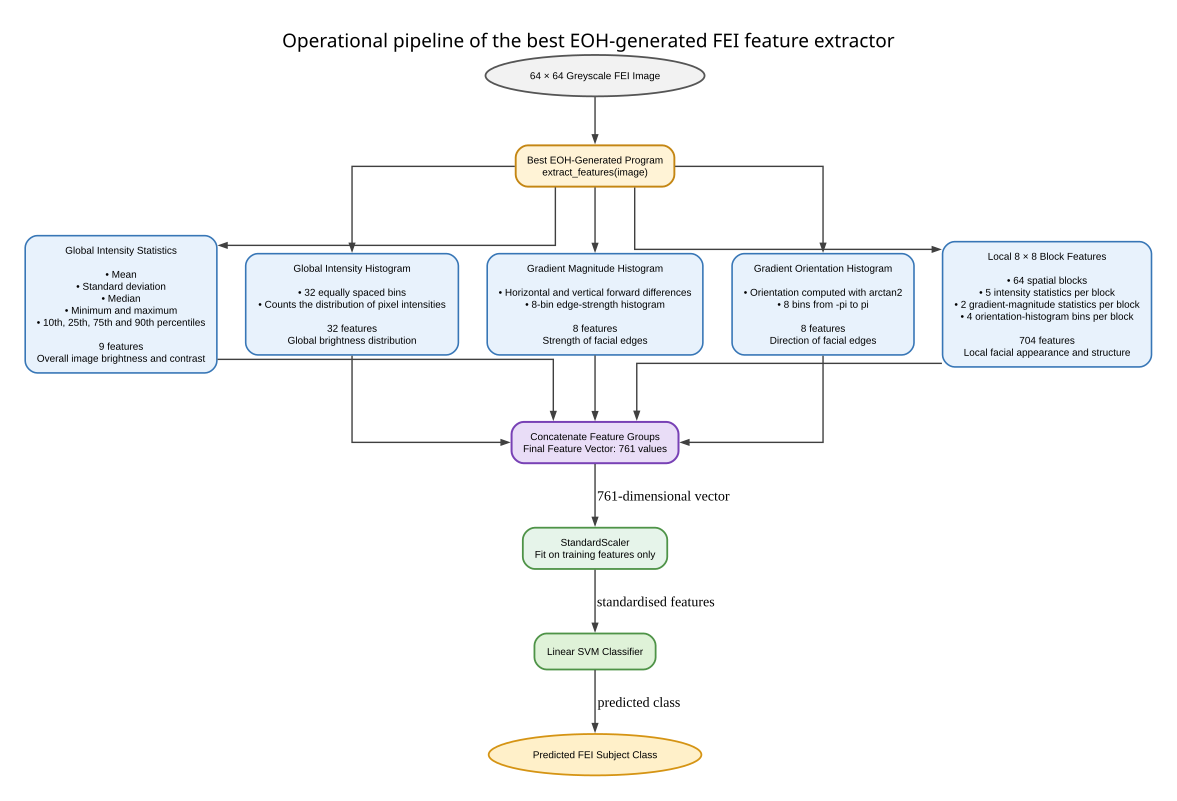

In [35]:
from pathlib import Path
import os

from graphviz import Digraph
from IPython.display import display, SVG

# ------------------------------------------------------------
# OPTIONAL WINDOWS GRAPHVIZ PATH
# ------------------------------------------------------------
# Keep this line if Graphviz is installed in the default Windows location.
# It is harmless when the directory is already available on PATH.
graphviz_windows_bin = Path(r"C:\Program Files\Graphviz\bin")

if graphviz_windows_bin.exists():
    os.environ["PATH"] += os.pathsep + str(graphviz_windows_bin)


# ------------------------------------------------------------
# OUTPUT SETTINGS
# ------------------------------------------------------------
PIPELINE_OUTPUT_DIRECTORY = PROJECT_ROOT / "figures"
PIPELINE_OUTPUT_STEM = "best_eoh_fei_feature_pipeline"

PIPELINE_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# FEATURE-GROUP DESCRIPTION
# ------------------------------------------------------------
# These groups are taken directly from best_smoke_test_program.py.
#
# Global features:
#   5 summary statistics
#   4 percentiles
#   32 intensity-histogram bins
#   8 gradient-magnitude bins
#   8 gradient-orientation bins
#
# Local features:
#   64 image blocks
#   11 features per block
#
# Total:
#   5 + 4 + 32 + 8 + 8 + (64 * 11) = 761

feature_groups = [
    {
        "node_id": "global_statistics",
        "title": "Global Intensity Statistics",
        "details": [
            "Mean",
            "Standard deviation",
            "Median",
            "Minimum and maximum",
            "10th, 25th, 75th and 90th percentiles",
        ],
        "feature_count": 9,
        "interpretation": "Overall image brightness and contrast",
    },
    {
        "node_id": "intensity_histogram",
        "title": "Global Intensity Histogram",
        "details": [
            "32 equally spaced bins",
            "Counts the distribution of pixel intensities",
        ],
        "feature_count": 32,
        "interpretation": "Global brightness distribution",
    },
    {
        "node_id": "gradient_magnitude",
        "title": "Gradient Magnitude Histogram",
        "details": [
            "Horizontal and vertical forward differences",
            "8-bin edge-strength histogram",
        ],
        "feature_count": 8,
        "interpretation": "Strength of facial edges",
    },
    {
        "node_id": "gradient_orientation",
        "title": "Gradient Orientation Histogram",
        "details": [
            "Orientation computed with arctan2",
            "8 bins from -pi to pi",
        ],
        "feature_count": 8,
        "interpretation": "Direction of facial edges",
    },
    {
        "node_id": "local_blocks",
        "title": "Local 8 × 8 Block Features",
        "details": [
            "64 spatial blocks",
            "5 intensity statistics per block",
            "2 gradient-magnitude statistics per block",
            "4 orientation-histogram bins per block",
        ],
        "feature_count": 704,
        "interpretation": "Local facial appearance and structure",
    },
]

total_feature_count = sum(
    group["feature_count"]
    for group in feature_groups
)

if total_feature_count != 761:
    raise RuntimeError(
        f"Expected 761 features, but calculated {total_feature_count}."
    )


# ------------------------------------------------------------
# PRINT A TEXT SUMMARY
# ------------------------------------------------------------
print("BEST EOH-GENERATED FEI FEATURE PIPELINE")
print("=" * 76)

for group_number, group in enumerate(feature_groups, start=1):
    print(
        f"{group_number}. {group['title']} "
        f"({group['feature_count']} features)"
    )
    print(f"   Interpretation: {group['interpretation']}")

print("-" * 76)
print(f"Total feature-vector length: {total_feature_count}")
print("Classifier: StandardScaler followed by LinearSVC")
print("Prediction: FEI subject identity class")


# ------------------------------------------------------------
# CREATE THE PIPELINE DIAGRAM
# ------------------------------------------------------------
pipeline_graph = Digraph(
    name="Best_EOH_FEI_Feature_Pipeline",
    format="svg",
)

pipeline_graph.attr(
    rankdir="TB",
    bgcolor="white",
    pad="0.35",
    nodesep="0.40",
    ranksep="0.65",
    splines="ortho",
    label=(
        "Operational pipeline of the best "
        "EOH-generated FEI feature extractor"
    ),
    labelloc="t",
    fontsize="19",
    fontname="Arial Bold",
)

pipeline_graph.attr(
    "node",
    fontname="Arial",
    fontsize="10",
    margin="0.18,0.12",
)

pipeline_graph.attr(
    "edge",
    color="#404040",
    penwidth="1.4",
    arrowsize="0.75",
)


# Input
pipeline_graph.node(
    "input_image",
    "64 × 64 Greyscale FEI Image",
    shape="ellipse",
    style="filled",
    fillcolor="#F2F2F2",
    color="#555555",
    penwidth="1.8",
)


# LLM-generated program
pipeline_graph.node(
    "generated_program",
    (
        "Best EOH-Generated Program\n"
        "extract_features(image)"
    ),
    shape="box",
    style="rounded,filled",
    fillcolor="#FFF3D6",
    color="#C48613",
    penwidth="1.9",
)

pipeline_graph.edge(
    "input_image",
    "generated_program",
)


# Interpretable feature branches
feature_node_ids = []

for group in feature_groups:
    node_id = group["node_id"]
    feature_node_ids.append(node_id)

    detail_text = "\n".join(
        f"• {detail}"
        for detail in group["details"]
    )

    node_label = (
        f"{group['title']}\n\n"
        f"{detail_text}\n\n"
        f"{group['feature_count']} features\n"
        f"{group['interpretation']}"
    )

    pipeline_graph.node(
        node_id,
        node_label,
        shape="box",
        style="rounded,filled",
        fillcolor="#E8F2FC",
        color="#3776B6",
        penwidth="1.6",
    )

    pipeline_graph.edge(
        "generated_program",
        node_id,
    )


# Keep the five feature groups aligned.
with pipeline_graph.subgraph() as same_rank:
    same_rank.attr(rank="same")

    for node_id in feature_node_ids:
        same_rank.node(node_id)


# Feature vector
pipeline_graph.node(
    "feature_vector",
    (
        "Concatenate Feature Groups\n"
        f"Final Feature Vector: {total_feature_count} values"
    ),
    shape="box",
    style="rounded,filled",
    fillcolor="#E9DDF7",
    color="#7841B5",
    penwidth="2.0",
)

for node_id in feature_node_ids:
    pipeline_graph.edge(
        node_id,
        "feature_vector",
    )


# Standardisation
pipeline_graph.node(
    "standard_scaler",
    (
        "StandardScaler\n"
        "Fit on training features only"
    ),
    shape="box",
    style="rounded,filled",
    fillcolor="#E6F4EA",
    color="#4E9347",
    penwidth="1.8",
)


# Classifier
pipeline_graph.node(
    "classifier",
    "Linear SVM Classifier",
    shape="box",
    style="rounded,filled",
    fillcolor="#DFF2D8",
    color="#4E9347",
    penwidth="1.8",
)


# Prediction
pipeline_graph.node(
    "prediction",
    "Predicted FEI Subject Class",
    shape="ellipse",
    style="filled",
    fillcolor="#FFF0C9",
    color="#D59414",
    penwidth="1.8",
)


pipeline_graph.edge(
    "feature_vector",
    "standard_scaler",
    label=" 761-dimensional vector ",
)

pipeline_graph.edge(
    "standard_scaler",
    "classifier",
    label=" standardised features ",
)

pipeline_graph.edge(
    "classifier",
    "prediction",
    label=" predicted class ",
)


# ------------------------------------------------------------
# SAVE SVG, PNG AND PDF
# ------------------------------------------------------------
pipeline_base_path = (
    PIPELINE_OUTPUT_DIRECTORY
    / PIPELINE_OUTPUT_STEM
)

pipeline_saved_paths = {}

for output_format in ("svg", "png", "pdf"):
    pipeline_graph.format = output_format

    saved_path = pipeline_graph.render(
        filename=str(pipeline_base_path),
        cleanup=True,
    )

    pipeline_saved_paths[output_format] = Path(saved_path)


print()
print("Saved EOH pipeline diagrams")
print("-" * 76)

for output_format, saved_path in pipeline_saved_paths.items():
    print(
        f"{output_format.upper()}: "
        f"{saved_path.resolve()}"
    )


# ------------------------------------------------------------
# DISPLAY IN THE NOTEBOOK
# ------------------------------------------------------------
display(
    SVG(
        filename=str(
            pipeline_saved_paths["svg"]
        )
    )
)
